# Etapa 3 — Modelagem

Entrada: `../data/processed/dataset.csv`, da Etapa 2.
Saída: um classificador treinado, avaliado e interpretado, e um ranking dos
melhores horários da janela.

Um detalhe que define esta etapa: **não existe label pronta.** O site
classifica as condições para pesca, não para surf — e pesca gosta de mar
calmo, quase o oposto. Definir o que é uma condição boa para surfar é a
primeira tarefa aqui, e é uma decisão sua.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

DIR_PROC = Path("..") / "data" / "processed"
sns.set_theme(style="whitegrid", context="notebook")

## 1. Carregar o dataset processado

Confira que veio o que você espera: número de linhas, tipos, nulos. Se a
Etapa 2 mudou, isso aparece aqui.

In [2]:
df = pd.read_csv(DIR_PROC / "dataset.csv", parse_dates=["datetime"])
df["dia"] = df["datetime"].dt.date
print(df.shape, "| nulos:", int(df.isna().sum().sum()))
df.dtypes

(168, 19) | nulos: 0


datetime         datetime64[us]
altura_onda_m           float64
direcao_onda                str
onda_graus              float64
vento_kmh               float64
direcao_vento               str
vento_graus             float64
mare_m                  float64
mare_subindo              int64
coeficiente               int64
fase_lua                  int64
hora                      int64
dia_semana                int64
periodo                     str
onda_sen                float64
onda_cos                float64
vento_sen               float64
vento_cos               float64
dia                      object
dtype: object

Vieram as 168 linhas do dataset, sem nulos e com os tipos certos.

## 2. Definir a label

Escreva, em código, a regra que separa condições ruins, boas e ótimas (ou
outro conjunto de classes, se preferir).

- Quais variáveis entram na regra: altura da onda, vento, maré, direção?
- Quais limiares? De onde vem o número — leitura, conversa com surfista,
  distribuição dos próprios dados? Registre a origem, mesmo que seja um chute
  informado.
- Como as classes ficaram distribuídas? Se 95% das horas caírem numa classe,
  a métrica do modelo vai mentir para você.

Documente a regra em markdown antes de seguir. Tudo depois disso depende dela.

### A regra

Cada hora ganha pontos de 0 a 5:

| Variável | Pontos |
|---|---|
| Onda | 2 se `>= 1,3 m`, 1 se `>= 1,1 m`, 0 abaixo |
| Vento | 2 se `<= 19 km/h`, 1 se `<= 23 km/h`, 0 acima |
| Maré | 1 se a altura está entre 0,8 e 1,8 m (maré intermediária), 0 fora |

Classes: **ruim** (0 a 1 ponto), **boa** (2 a 3) e **ótima** (4 a 5).

**De onde vêm os números.** São um chute informado, sem referência de surfista. Escolhi os limiares olhando a distribuição dos dados: onda de 1,3 m é o topo da janela e 1,1 m é perto da mediana, e o vento de 19 e 23 km/h separa as horas mais calmas das típicas. Assumi que onda maior e vento mais fraco são melhores, e que a maré intermediária é melhor que a muito cheia ou muito vazia (suposição minha, os dados não confirmam).

**Direção do vento fica de fora** porque ela é sempre do mar para a terra nesta janela, então não separa nenhuma hora de outra.

In [3]:
def pontuar(linha):
    pontos = 0

    if linha["altura_onda_m"] >= 1.3:
        pontos += 2
    elif linha["altura_onda_m"] >= 1.1:
        pontos += 1

    if linha["vento_kmh"] <= 19:
        pontos += 2
    elif linha["vento_kmh"] <= 23:
        pontos += 1

    if 0.8 <= linha["mare_m"] <= 1.8:
        pontos += 1

    return pontos

df["pontos"] = df.apply(pontuar, axis=1)
df["classe"] = pd.cut(df["pontos"], bins=[-1, 1, 3, 5], labels=["ruim", "boa", "otima"])
print(df["classe"].value_counts().to_string())
print()
print(pd.crosstab(df["dia"], df["classe"]))

classe
boa      79
ruim     69
otima    20

classe      ruim  boa  otima
dia                         
2026-10-08     5   17      2
2026-10-09    17    7      0
2026-10-10    13   11      0
2026-10-11    17    7      0
2026-10-12    10   14      0
2026-10-13     7   12      5
2026-10-14     0   11     13


As classes ficaram em 69 ruins, 79 boas e 20 ótimas, então nenhuma domina. A classe ótima é a menor e só aparece em 08, 13 e 14/10. O dia 14/10 não tem nenhuma hora ruim, e os dias 09 a 11/10 têm poucas horas boas.

## 3. Features e alvo

Separe `X` e `y`.

- Quais colunas entram como feature? Cuidado: usar diretamente as variáveis da
  sua regra faz o modelo apenas redescobrir o `if` que você escreveu. Isso é
  esperado aqui — mas você precisa saber que é isso que está acontecendo.
- Direção do vento e da onda são texto. Como transformar em número sem inventar
  uma ordem que não existe?

In [4]:
FEATURES = ["altura_onda_m", "vento_kmh", "mare_m", "mare_subindo", "hora", "coeficiente",
            "vento_sen", "vento_cos", "onda_sen", "onda_cos"]
X = df[FEATURES]
y = df["classe"].astype(str)
grupos = df["dia"]
print(X.shape, y.value_counts().to_dict())

(168, 10) {'boa': 79, 'ruim': 69, 'otima': 20}


As features são onda, vento, maré, hora, coeficiente e as direções em seno e cosseno. Como onda, vento e maré estão na regra, o modelo vai principalmente redescobrir a regra que eu escrevi.

## 4. Treino e teste

Divida os dados. Vale estratificar pelas classes? A ordem temporal importa —
sortear linhas de um mesmo dia entre treino e teste vaza informação?

In [5]:
dias_teste = [pd.Timestamp("2026-10-11").date(), pd.Timestamp("2026-10-13").date()]
mascara_teste = df["dia"].isin(dias_teste)
X_treino, y_treino = X[~mascara_teste], y[~mascara_teste]
X_teste, y_teste = X[mascara_teste], y[mascara_teste]
print("treino:", len(X_treino), y_treino.value_counts().to_dict())
print("teste:", len(X_teste), y_teste.value_counts().to_dict())

treino: 120 {'boa': 60, 'ruim': 45, 'otima': 15}
teste: 48 {'ruim': 24, 'boa': 19, 'otima': 5}


Separei por dia, e não por linha, porque horas vizinhas são quase iguais e sortear linhas deixaria o modelo ver o "gabarito" no treino. O teste usa 11 e 13/10 e o treino usa os outros cinco dias. As três classes aparecem nos dois lados.

## 5. Treinar

Treine pelo menos dois modelos de famílias diferentes (por exemplo uma árvore
e um modelo baseado em distância) para ter com o que comparar.

In [6]:
arvore = DecisionTreeClassifier(max_depth=4, random_state=0)
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7))
modelos = {"Árvore de decisão": arvore, "KNN": knn}
for modelo in modelos.values():
    modelo.fit(X_treino, y_treino)

Treinei uma árvore de decisão e um KNN, que são de famílias diferentes. A árvore decide por cortes em cada variável, e o KNN compara cada hora com as horas mais parecidas.

## 6. Avaliar

- Acurácia é suficiente aqui, com as classes desbalanceadas como estão?
- Olhe a matriz de confusão: que erro o modelo comete?
- Um único split é confiável com poucas linhas, ou vale validação cruzada?

baseline (sempre 'boa'): acurácia 0.40

Árvore de decisão
              precision    recall  f1-score   support

        ruim       0.92      1.00      0.96        24
         boa       1.00      0.84      0.91        19
       otima       0.83      1.00      0.91         5

    accuracy                           0.94        48
   macro avg       0.92      0.95      0.93        48
weighted avg       0.94      0.94      0.94        48

KNN
              precision    recall  f1-score   support

        ruim       0.90      0.38      0.53        24
         boa       0.47      0.89      0.62        19
       otima       0.50      0.20      0.29         5

    accuracy                           0.56        48
   macro avg       0.62      0.49      0.48        48
weighted avg       0.69      0.56      0.54        48



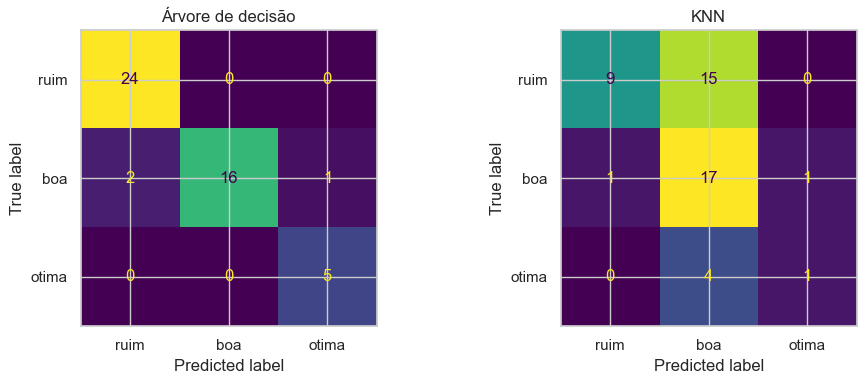

In [7]:
ordem = ["ruim", "boa", "otima"]
maioria = y_treino.value_counts().idxmax()
print(f"baseline (sempre '{maioria}'): acurácia {(y_teste == maioria).mean():.2f}\n")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nome, modelo) in zip(axs, modelos.items()):
    pred = modelo.predict(X_teste)
    print(nome)
    print(classification_report(y_teste, pred, labels=ordem, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_teste, pred, labels=ordem, ax=ax, colorbar=False)
    ax.set_title(nome)
plt.tight_layout()
plt.show()

In [8]:
logo = LeaveOneGroupOut()
resultado = []
for nome, modelo in modelos.items():
    pred = cross_val_predict(modelo, X, y, groups=grupos, cv=logo)
    resultado.append({"modelo": nome, "acurácia": (pred == y).mean(), "F1 macro": f1_score(y, pred, average="macro")})
pd.DataFrame(resultado).round(2)

,modelo,acurácia,F1 macro
0,Árvore de decisão,0.83,0.84
1,KNN,0.61,0.60


Sempre chutar "boa" acerta 40%. A árvore chega a 94% no teste, e o KNN a 56%. Com validação cruzada deixando um dia de fora, a árvore cai para 83% e o KNN para 61%, então o número do split único estava otimista. A árvore erra mais ao chamar de "ruim" algumas horas que eram "boa". O KNN erra mais porque mistura variáveis que não entram na regra (hora, coeficiente, direções) na hora de medir a distância.

## 7. Interpretar

Um modelo que acerta e você não sabe por quê não serve para responder nada.

- Plote a árvore. Os cortes que ela encontrou parecem com os seus limiares?
- Quais features o modelo considera mais importantes? Bate com sua intuição?
- Se a acurácia veio altíssima, explique o motivo — não celebre.

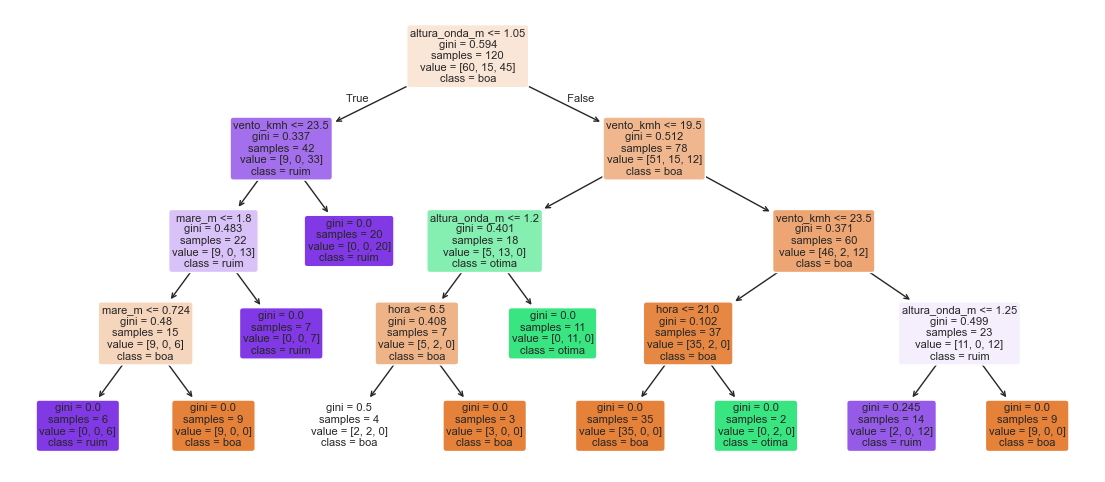

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(arvore, feature_names=FEATURES, class_names=list(arvore.classes_), filled=True, rounded=True, fontsize=8, ax=ax)
plt.show()

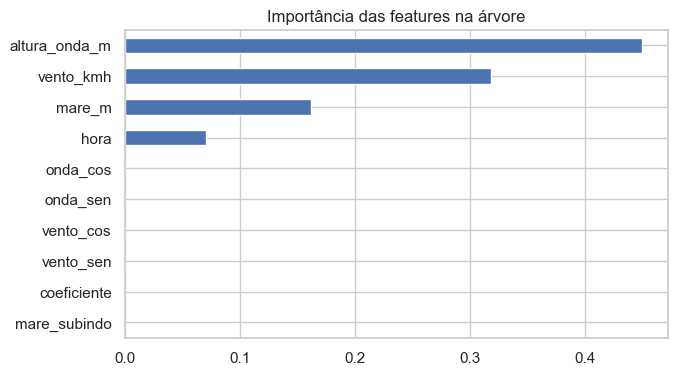

altura_onda_m    0.45
vento_kmh        0.32
mare_m           0.16
hora             0.07
mare_subindo     0.00
dtype: float64

In [10]:
importancias = pd.Series(arvore.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importancias.plot.barh(ax=ax)
ax.set(title="Importância das features na árvore")
plt.show()
importancias.round(2).sort_values(ascending=False).head(5)

Os cortes da árvore são parecidos com os meus limiares: onda em 1,05 m e 1,2 m (usei 1,1 e 1,3) e vento em 19,5 e 23,5 km/h (usei 19 e 23). Como a onda só tem valores em degraus de 0,1 m, o corte de 1,05 é o mesmo que 1,1. As features mais importantes são onda (0,45), vento (0,32) e maré (0,16), que são justamente as da regra. A hora aparece pouco (0,07) e acho que é ruído, porque os cortes em 6,5 h e 21 h só separam poucas linhas. A acurácia alta tem uma explicação simples: o modelo aprendeu a copiar a minha regra.

## 8. Responder a pergunta

Aplique o modelo na janela inteira e produza a resposta para Felipe e Nicholas:

- Quais os melhores dias da janela de previsão?
- Em média, qual o melhor horário do dia?
- Em que grau essa resposta é uma previsão do mar, e em que grau é apenas a
  sua regra reescrita?

In [11]:
modelo_final = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X, y)
proba = pd.DataFrame(modelo_final.predict_proba(X), columns=modelo_final.classes_, index=df.index)
df["nota"] = proba["boa"] + 2 * proba["otima"]

por_dia = df.groupby("dia")[["nota", "pontos", "altura_onda_m", "vento_kmh"]].mean().round(2).sort_values("nota", ascending=False)
por_dia

,nota,pontos,altura_onda_m,vento_kmh
dia,,,,
2026-10-14,1.54,3.62,1.34,20.71
2026-10-08,0.95,2.21,1.07,21.04
2026-10-13,0.87,2.46,1.22,21.79
2026-10-12,0.58,1.88,1.21,23.62
2026-10-10,0.50,1.42,1.03,22.67
2026-10-11,0.27,1.08,1.00,22.83
2026-10-09,0.23,0.92,1.02,23.58


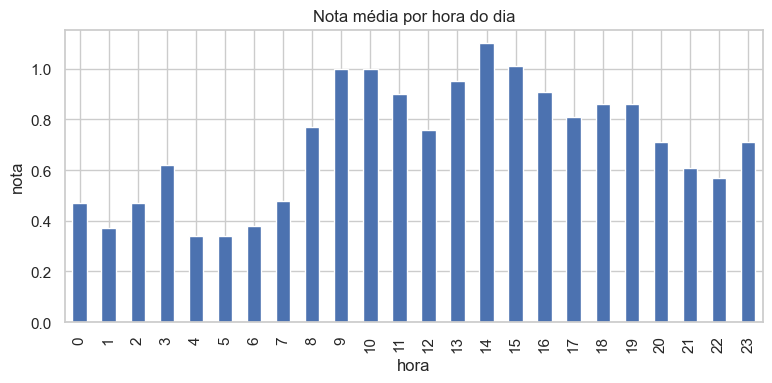

melhores horas: {14: 1.1, 15: 1.01, 9: 1.0, 10: 1.0, 13: 0.95}


,datetime,altura_onda_m,vento_kmh,mare_m,classe,nota
134,2026-10-13 14:00:00,1.3,19.0,0.854700,otima,2.0
135,2026-10-13 15:00:00,1.3,19.0,1.283172,otima,2.0
153,2026-10-14 09:00:00,1.4,15.0,1.767662,otima,2.0
154,2026-10-14 10:00:00,1.4,17.0,1.336937,otima,2.0
155,2026-10-14 11:00:00,1.4,19.0,0.935702,otima,2.0
159,2026-10-14 15:00:00,1.4,18.0,1.073978,otima,2.0
160,2026-10-14 16:00:00,1.4,16.0,1.479490,otima,2.0
133,2026-10-13 13:00:00,1.3,19.0,0.570768,otima,2.0


In [12]:
por_hora = df.groupby("hora")["nota"].mean().round(2)
fig, ax = plt.subplots(figsize=(9, 3.8))
por_hora.plot.bar(ax=ax)
ax.set(title="Nota média por hora do dia", xlabel="hora", ylabel="nota")
plt.show()
print("melhores horas:", por_hora.sort_values(ascending=False).head(5).to_dict())
df.sort_values(["nota", "pontos"], ascending=False).head(8)[["datetime", "altura_onda_m", "vento_kmh", "mare_m", "classe", "nota"]]

Dei uma nota a cada hora (probabilidade de "boa" mais duas vezes a de "ótima") e fiz a média por dia. O dia **14/10** é o melhor, com nota 1,54 e onda média de 1,34 m. Depois vêm 08/10 e 13/10. Os dias 09 e 11/10 são os piores. Pela média da janela, as melhores horas são 14h e 15h, depois 9h e 10h. As 8 melhores horas individuais são todas de 13 e 14/10, de manhã e à tarde.

## 9. Conclusão e limites

Em texto:

1. A recomendação, em uma frase.
2. O teto deste modelo: ele reproduz a sua heurística, então é tão bom quanto
   ela. O que faria dela uma regra melhor?
3. O que a janela de ~7 dias e o volume de linhas impedem de afirmar.
4. Como você responderia "qual a melhor época do ano para surfar em João
   Pessoa" — que dado faltaria, e como coletá-lo.

1. **Recomendação.** Voltar em 14/10, de 9h às 17h, quando a onda chega a 1,4 m e o vento fica entre 13 e 18 km/h. Se não der, 13/10 à tarde.
2. **Teto do modelo.** Ele só copia a minha regra, então não prevê o mar. A regra seria melhor com limiares vindos de um surfista, com o período da onda e com a direção do vento (que aqui nunca varia).
3. **O que a janela impede de afirmar.** Só há 7 dias de uma semana de outubro e 168 linhas muito parecidas entre si. Não dá para dizer se 14/10 é bom para o ano todo, nem se a previsão vai se confirmar.
4. **Melhor época do ano.** Faltam ondas e vento de vários meses. Eu coletaria a previsão todos os dias por um ano (ou usaria dados históricos de boia ou de reanálise), rodaria a mesma regra e compararia os meses.